
## 习题 1-6
本题用于检验 **条件数condition number**的概念。研究当向 $b$ 中加入噪声时，求解线性系统 $Ax=b$ 的精度如何随矩阵 $A$ 的条件数变化。

### (a)
构造两个矩阵。

先生成随机矩阵：

$U\in\mathbb{R}^{100\times 100},\qquad V\in\mathbb{R}^{100\times 100}$，

然后构造两个不同的 $\Sigma$：

1. 第一个 $\Sigma$ 的奇异值按对数间隔从 $100$ 到 $1$ 排列；
2. 第二个 $\Sigma$ 的奇异值按对数间隔从 $100$ 到 $10^{-6}$ 排列。

由此构造两个 $A$ 矩阵：

- 一个条件数为 $100$；
- 一个条件数为 $10^8$。

再生成一个随机向量 $b$，分别求解对应的 $x$，并比较结果。

然后向 $b$ 中加入一个小扰动 $\varepsilon$，使其范数比 $b$ 的范数小 $10^{-6}$ 倍。再用新的 $b+\varepsilon$ 求解 $x$，并比较结果。

### (b)
重复上述实验多次，使用许多不同的噪声向量 $\varepsilon$，并计算误差分布。

将误差画成直方图，并解释其形状。

### (c)
重复上述实验，但比较两种不同奇异值分布的 $A$：

1. 第一个 $\Sigma$ 的奇异值从 $100$ 到 $1$ **线性间隔**排列；
2. 第二个 $\Sigma$ 的奇异值从 $100$ 到 $1$ **对数间隔**排列。

观察结果是否发生变化，并解释原因。

### (d)
再次重复上述实验，但这次令矩阵 $A$ 的大小为 $100\times 10$。

解释出现的变化。


In [1]:
import numpy as np
import matplotlib.pyplot as plt

Task1.1:构造两个矩阵。
先生成随机矩阵：
$U\in\mathbb{R}^{100\times 100},\qquad V\in\mathbb{R}^{100\times 100}$，
然后构造两个不同的 $\Sigma$：
1. 第一个 $\Sigma$ 的奇异值按对数间隔从 $100$ 到 $1$ 排列；
2. 第二个 $\Sigma$ 的奇异值按对数间隔从 $100$ 到 $10^{-6}$ 排列。

In [2]:
# 生成随机矩阵
X1 = np.random.randn(100, 100)
X2 = np.random.randn(100, 100)

# 执行 SVD 分解
U, _, _ = np.linalg.svd(X1)
V, _, _ = np.linalg.svd(X2) 

In [3]:
# 再构造Sigma
Sigma_diag_1 = np.logspace(2,0,100)
Sigma_diag_2 = np.logspace(2,-6,100)
Sigma_1 = np.diag(Sigma_diag_1)
Sigma_2 = np.diag(Sigma_diag_2)

Task1.2
由此构造两个 $A$ 矩阵：

- 一个条件数为 $100$；
- 一个条件数为 $10^8$。

In [4]:
# 最后构造A
A_1 = U @ Sigma_1 @ V.T
A_2 = U @ Sigma_2 @ V.T

Task1.3: 再生成一个随机向量 $b$，分别求解对应的 $x$，并比较结果。

In [5]:
b = np.random.randn(100)

In [6]:
# 求解x
x_1 = np.linalg.solve(A_1,b)
x_2 = np.linalg.solve(A_2,b)
x_1,x_2

(array([-0.16448842, -0.23407788, -0.19326457, -0.2098802 ,  0.46258959,
         0.35676069,  0.41941033,  0.36409841,  0.44007632,  0.16085748,
        -0.030453  ,  0.29909013,  0.37166383,  0.25505541,  0.33281493,
        -0.21202298,  0.18677346,  0.12310644,  0.88039019,  0.11362071,
         0.17290278, -0.16334899,  0.30144576,  0.31206629,  0.56766698,
        -0.4356604 , -0.49061378, -0.26313421,  0.49334339,  0.15114324,
         0.12197472,  0.1670345 ,  0.11249956, -0.06463074, -0.0116168 ,
         0.475597  , -0.3187518 ,  0.10903815, -0.39514093,  0.33908539,
         0.26019395,  0.16322179, -0.06538143, -0.09596251,  0.23057678,
        -0.29301863,  0.01386362,  0.1447647 , -0.1020321 , -0.29426979,
        -0.58489422, -0.21938146,  0.18552173, -0.51147359, -0.19091048,
         0.21283841, -0.04559789, -0.17469765,  0.21852631, -0.30976148,
         0.46147533, -0.58227357, -0.41655694,  0.30471098,  0.09554317,
        -0.31432886,  0.13976904, -0.09570862,  0.0

Task1.4: 向 $b$ 中加入一个小扰动 $\varepsilon$，使其范数比 $b$ 的范数小 $10^{-6}$ 倍。再用新的 $b+\varepsilon$ 求解 $x$，并比较结果。

In [7]:
# 加入扰动
epsilon = np.random.randn(100)
b_noisy = b + epsilon/np.linalg.norm(epsilon) * 1e-6 * np.linalg.norm(b)

In [8]:
x_1_noisy = np.linalg.solve(A_1, b_noisy)
x_2_noisy = np.linalg.solve(A_2, b_noisy)
x_1_noisy,x_2_noisy

(array([-0.16448857, -0.23407776, -0.19326456, -0.20988028,  0.46258964,
         0.35676088,  0.41941034,  0.36409809,  0.44007657,  0.16085752,
        -0.03045283,  0.29909009,  0.37166385,  0.25505503,  0.33281477,
        -0.21202286,  0.18677339,  0.12310624,  0.88038999,  0.11362111,
         0.17290305, -0.16334936,  0.3014453 ,  0.31206617,  0.56766749,
        -0.43566063, -0.49061422, -0.26313461,  0.49334315,  0.15114331,
         0.12197465,  0.16703441,  0.11249962, -0.06463055, -0.01161694,
         0.47559691, -0.31875198,  0.10903844, -0.39514111,  0.33908548,
         0.26019336,  0.16322114, -0.06538122, -0.09596201,  0.2305765 ,
        -0.29301902,  0.0138639 ,  0.14476481, -0.10203237, -0.29426916,
        -0.58489366, -0.21938168,  0.18552184, -0.51147333, -0.19091078,
         0.21283832, -0.04559797, -0.1746974 ,  0.2185262 , -0.30976177,
         0.46147522, -0.58227324, -0.41655684,  0.30471063,  0.09554328,
        -0.31432862,  0.13976917, -0.09570901,  0.0

In [9]:
error_1 = np.linalg.norm(x_1 - x_1_noisy) / np.linalg.norm(x_1)
error_2 = np.linalg.norm(x_2 - x_2_noisy) / np.linalg.norm(x_2)
error_1, error_2

(np.float64(9.905097722218089e-07), np.float64(7.341666237202316e-07))

Task2: 重复上述实验多次，使用许多不同的噪声向量 $\varepsilon$，并计算误差分布。将误差画成直方图，并解释其形状。

In [10]:
error_1_array=[]
error_2_array=[]
for i in range(1000):
    epsilon = np.random.randn(100)
    b_noisy = b + epsilon/np.linalg.norm(epsilon) * 1e-6 * np.linalg.norm(b)
    x_1_noisy = np.linalg.solve(A_1, b_noisy)
    x_2_noisy = np.linalg.solve(A_2, b_noisy)
    error_1 = np.linalg.norm(x_1 - x_1_noisy) / np.linalg.norm(x_1)
    error_2 = np.linalg.norm(x_2 - x_2_noisy) / np.linalg.norm(x_2)
    error_1_array.append(error_1)
    error_2_array.append(error_2)


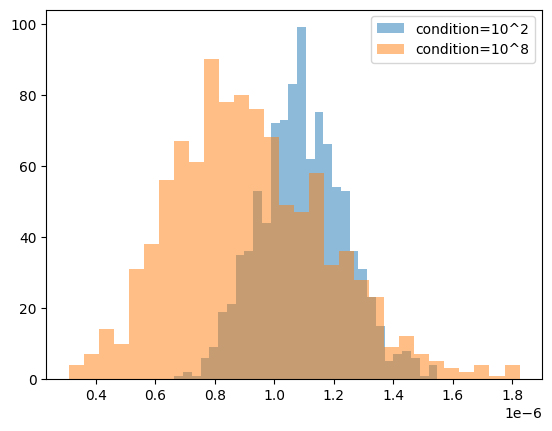

In [11]:
plt.hist(error_1_array,bins=30,alpha=0.5,label=f'condition=10^2')
plt.hist(error_2_array,bins=30,alpha=0.5,label=f'condition=10^8')
plt.legend(loc='best')
plt.show()

Task3: 重复上述实验，但比较两种不同奇异值分布的 $A$：
1. 第一个 $\Sigma$ 的奇异值从 $100$ 到 $1$ **线性间隔**排列；
2. 第二个 $\Sigma$ 的奇异值从 $100$ 到 $1$ **对数间隔**排列。

观察结果是否发生变化，并解释原因。

Task3.1: 生成两个矩阵：
1. 第一个 $\Sigma$ 的奇异值从 $100$ 到 $1$ **线性间隔**排列；
2. 第二个 $\Sigma$ 的奇异值从 $100$ 到 $1$ **对数间隔**排列。

In [12]:
# 先构造Sigma
Sigma_3_1_diag = np.linspace(100,1,100)
Sigma_3_2_diag = np.logspace(2,0,100)
Sigma_3_1 = np.diag(Sigma_3_1_diag)
Sigma_3_2 = np.diag(Sigma_3_2_diag)

Task3.2: 重复之前的实验

In [13]:
# 最后构造A
A_3_1 = U @ Sigma_3_1 @ V.T
A_3_2 = U @ Sigma_3_2 @ V.T

In [14]:
# 求解x
x_3_1 = np.linalg.solve(A_3_1,b)
x_3_2 = np.linalg.solve(A_3_2,b)
x_3_1,x_3_2

(array([ 2.15352791e-02, -1.11029629e-01,  9.35580419e-02, -8.99103096e-02,
         2.15587413e-01,  1.78740674e-01,  7.09662688e-02,  3.89681987e-01,
         1.73651864e-01,  9.46824067e-02, -1.80215507e-01,  1.46028279e-01,
        -7.33346387e-02,  2.58673030e-01, -3.82123670e-02,  1.05254836e-01,
        -2.25517596e-02,  4.93725858e-02,  3.57885442e-01, -2.09433134e-01,
         8.31849163e-02, -6.28867297e-02, -1.14962555e-04,  1.00647878e-01,
         2.27375980e-01, -2.39858290e-01, -1.14653425e-01, -2.07694281e-01,
         2.42645759e-01,  1.20782401e-01,  7.54056745e-02, -1.79700348e-02,
         8.87452782e-02, -6.79231566e-03, -2.80697771e-02,  2.27882125e-01,
        -7.90968094e-02,  2.28636217e-02, -2.11060390e-01,  6.34393120e-02,
         1.37413625e-01, -5.11114770e-02,  1.96371929e-03,  1.85565261e-01,
         9.06583425e-02, -1.86875443e-01,  1.16052822e-01,  7.59508348e-03,
         1.50816361e-01, -1.46489406e-01, -3.41943610e-01, -1.41289470e-01,
         1.1

In [15]:
# 扰动同之前，不需要再加了

In [16]:
x_3_1_noisy = np.linalg.solve(A_3_1, b_noisy)
x_3_2_noisy = np.linalg.solve(A_3_2, b_noisy)
x_3_1_noisy,x_3_2_noisy

(array([ 2.15351928e-02, -1.11029630e-01,  9.35580434e-02, -8.99103172e-02,
         2.15587491e-01,  1.78740719e-01,  7.09664104e-02,  3.89682125e-01,
         1.73651772e-01,  9.46823144e-02, -1.80215520e-01,  1.46028308e-01,
        -7.33346442e-02,  2.58672965e-01, -3.82122035e-02,  1.05254773e-01,
        -2.25517109e-02,  4.93725685e-02,  3.57885357e-01, -2.09433163e-01,
         8.31848392e-02, -6.28867139e-02, -1.14907199e-04,  1.00647979e-01,
         2.27375894e-01, -2.39858254e-01, -1.14653302e-01, -2.07694203e-01,
         2.42645824e-01,  1.20782337e-01,  7.54056015e-02, -1.79700636e-02,
         8.87452393e-02, -6.79248339e-03, -2.80698662e-02,  2.27881823e-01,
        -7.90968759e-02,  2.28636729e-02, -2.11060378e-01,  6.34392337e-02,
         1.37413736e-01, -5.11113971e-02,  1.96379376e-03,  1.85565195e-01,
         9.06583575e-02, -1.86875298e-01,  1.16052931e-01,  7.59490772e-03,
         1.50816191e-01, -1.46489402e-01, -3.41943449e-01, -1.41289499e-01,
         1.1

In [17]:
error_3_1 = np.linalg.norm(x_3_1 - x_3_1_noisy) / np.linalg.norm(x_3_1)
error_3_2 = np.linalg.norm(x_3_2 - x_3_2_noisy) / np.linalg.norm(x_3_2)
error_3_1, error_3_2

(np.float64(7.073277082938465e-07), np.float64(1.2492238034827365e-06))

In [18]:
error_3_1_array=[]
error_3_2_array=[]
for i in range(1000):
    epsilon = np.random.randn(100)
    b_noisy = b + epsilon/np.linalg.norm(epsilon) * 1e-6 * np.linalg.norm(b)
    x_3_1_noisy = np.linalg.solve(A_3_1,b_noisy)
    x_3_2_noisy = np.linalg.solve(A_3_2, b_noisy)
    error_3_1 = np.linalg.norm(x_3_1 - x_3_1_noisy) / np.linalg.norm(x_3_1)
    error_3_2 = np.linalg.norm(x_3_2 - x_3_2_noisy) / np.linalg.norm(x_3_2)
    error_3_1_array.append(error_3_1)
    error_3_2_array.append(error_3_2)

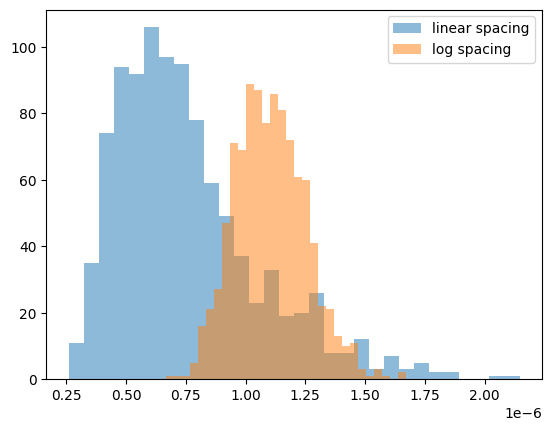

In [19]:
plt.hist(error_3_1_array,bins=30,alpha=0.5,label=f'linear spacing')
plt.hist(error_3_2_array,bins=30,alpha=0.5,label=f'log spacing')
plt.legend(loc='best')
plt.show()

Task4: 令矩阵 $A$ 的大小为 $100\times 10$

In [20]:
# 生成随机矩阵
X_4_1 = np.random.randn(100, 10)
X_4_2 = np.random.randn(10, 10)

# 执行 SVD 分解
U_4, _, _ = np.linalg.svd(X_4_1,full_matrices=False)
V_4, _, _ = np.linalg.svd(X_4_2,full_matrices=False) 

In [21]:
# 再构造Sigma
Sigma_diag_4_1 = np.logspace(2,0,10)
Sigma_diag_4_2 = np.logspace(2,-6,10)
Sigma_4_1 = np.diag(Sigma_diag_4_1)
Sigma_4_2 = np.diag(Sigma_diag_4_2)

In [22]:
# 最后构造A
A_4_1 = U_4 @ Sigma_4_1 @ V_4.T
A_4_2 = U_4 @ Sigma_4_2 @ V_4.T

In [23]:
b_4 = np.random.randn(100)

In [24]:
# 求解x
x_4_1 = np.linalg.pinv(A_4_1) @ b_4
x_4_2 = np.linalg.pinv(A_4_2) @ b_4

In [25]:
# 加入扰动
epsilon_4 = np.random.randn(100)
b_noisy_4 = b_4 + epsilon_4 / np.linalg.norm(epsilon_4) * 1e-6 * np.linalg.norm(b_4)

In [26]:
x_4_1_noisy = np.linalg.pinv(A_4_1) @ b_noisy_4
x_4_2_noisy = np.linalg.pinv(A_4_2) @ b_noisy_4
x_4_1_noisy,x_4_2_noisy

(array([ 0.23921396, -0.34934365,  0.22016065,  0.24318998, -0.57308214,
         0.37440229, -0.1980387 , -0.37838611, -0.13786742,  0.12163746]),
 array([ 103787.33204985, -113827.93785648,   88229.39473928,
         132059.84346257, -130395.36397381,  119299.06140701,
        -201585.4636588 , -269367.67544972,  197093.0340807 ,
         -39183.32913591]))

In [27]:
error_4_1 = np.linalg.norm(x_4_1 - x_4_1_noisy) / np.linalg.norm(x_4_1)
error_4_2 = np.linalg.norm(x_4_2 - x_4_2_noisy) / np.linalg.norm(x_4_2)
error_4_1, error_4_2

(np.float64(7.777977189088522e-07), np.float64(4.939332269471763e-07))

In [28]:
error_4_1_array=[]
error_4_2_array=[]
for i in range(1000):
    epsilon_4 = np.random.randn(100)
    b_noisy_4 = (b_4 + epsilon_4 / 
                 np.linalg.norm(epsilon_4) * 1e-6 * np.linalg.norm(b_4))
    x_4_1_noisy = np.linalg.pinv(A_4_1) @ b_noisy_4
    x_4_2_noisy = np.linalg.pinv(A_4_2) @ b_noisy_4
    error_4_1 = np.linalg.norm(x_4_1 - x_4_1_noisy) / np.linalg.norm(x_4_1)
    error_4_2 = np.linalg.norm(x_4_2 - x_4_2_noisy) / np.linalg.norm(x_4_2)
    error_4_1_array.append(error_4_1)
    error_4_2_array.append(error_4_2)

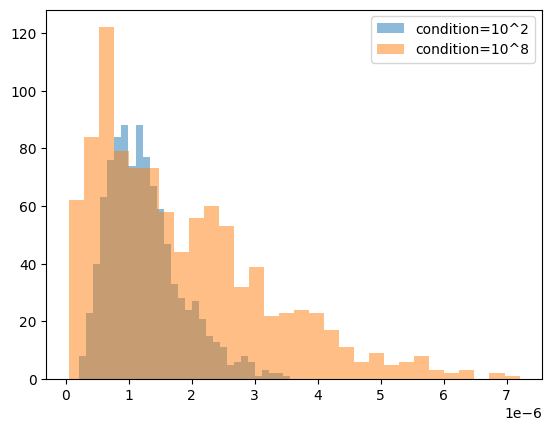

In [29]:
plt.hist(error_4_1_array,bins=30,alpha=0.5,label=f'condition=10^2')
plt.hist(error_4_2_array,bins=30,alpha=0.5,label=f'condition=10^8')
plt.legend(loc='best')
plt.show()